# EDA — Univariate Analysis

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

df = pd.read_csv('../data/processed/rideshare_cleaned.csv')
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Dataset shape: (637976, 37)
Columns: ['hour', 'day', 'month', 'source', 'destination', 'cab_type', 'name', 'price', 'distance', 'surge_multiplier', 'latitude', 'longitude', 'temperature', 'apparentTemperature', 'short_summary', 'precipIntensity', 'precipProbability', 'humidity', 'windSpeed', 'windGust', 'visibility', 'temperatureHigh', 'temperatureLow', 'apparentTemperatureHigh', 'apparentTemperatureLow', 'dewPoint', 'pressure', 'windBearing', 'cloudCover', 'uvIndex', 'ozone', 'moonPhase', 'precipIntensityMax', 'temperatureMin', 'temperatureMax', 'apparentTemperatureMin', 'apparentTemperatureMax']


In [54]:
df_encode = pd.read_csv('../data/processed/rideshare_encoded.csv')
print(f"Dataset shape: {df_encode.shape}")
print(f"Columns: {list(df_encode.columns)}")

Dataset shape: (637976, 44)
Columns: ['hour', 'day', 'month', 'source', 'destination', 'name', 'price', 'distance', 'surge_multiplier', 'latitude', 'longitude', 'temperature', 'apparentTemperature', 'precipIntensity', 'precipProbability', 'humidity', 'windSpeed', 'windGust', 'visibility', 'temperatureHigh', 'temperatureLow', 'apparentTemperatureHigh', 'apparentTemperatureLow', 'dewPoint', 'pressure', 'windBearing', 'cloudCover', 'uvIndex', 'ozone', 'moonPhase', 'precipIntensityMax', 'temperatureMin', 'temperatureMax', 'apparentTemperatureMin', 'apparentTemperatureMax', 'cab_type_Uber', 'short_summary_ Drizzle ', 'short_summary_ Foggy ', 'short_summary_ Light Rain ', 'short_summary_ Mostly Cloudy ', 'short_summary_ Overcast ', 'short_summary_ Partly Cloudy ', 'short_summary_ Possible Drizzle ', 'short_summary_ Rain ']


In [55]:
display(df.head(3))

,hour,day,month,source,destination,cab_type,name,price,distance,surge_multiplier,...,windBearing,cloudCover,uvIndex,ozone,moonPhase,precipIntensityMax,temperatureMin,temperatureMax,apparentTemperatureMin,apparentTemperatureMax
0,9,16,12,Haymarket Square,North Station,Lyft,Shared,5.0,0.44,1.0,...,57,0.72,0,303.8,0.30,0.1276,39.89,43.68,33.73,38.07
1,2,27,11,Haymarket Square,North Station,Lyft,Lux,11.0,0.44,1.0,...,90,1.00,0,291.1,0.64,0.1300,40.49,47.30,36.20,43.92
2,1,28,11,Haymarket Square,North Station,Lyft,Lyft,7.0,0.44,1.0,...,240,0.03,0,315.7,0.68,0.1064,35.36,47.55,31.04,44.12


#### FUNCTION SUMMARY

In [56]:
def quick_summary(col, df=df):
    s = df[col]
    print(f"  dtype     : {s.dtype}")
    print(f"  non-null  : {s.count():,}")
    print(f"  missing   : {s.isna().sum()} ({s.isna().mean()*100:.1f}%)")
    if pd.api.types.is_numeric_dtype(s):
        print(f"  min/max   : {s.min():.4g} / {s.max():.4g}")
        print(f"  mean±std  : {s.mean():.4g} ± {s.std():.4g}")
        print(f"  median    : {s.median():.4g}")
        print(f"  skewness  : {s.skew():.4f}")
    else:
        print(f"  unique    : {s.nunique()}")
        print(f"  top 5     :")
        print(s.value_counts().head())

# Part 1 — Target Variable

### 1.1 price

In [57]:
quick_summary('price')

  dtype     : float64
  non-null  : 637,976
  missing   : 0 (0.0%)
  min/max   : 2.5 / 97.5
  mean±std  : 16.55 ± 9.324
  median    : 13.5
  skewness  : 1.0457


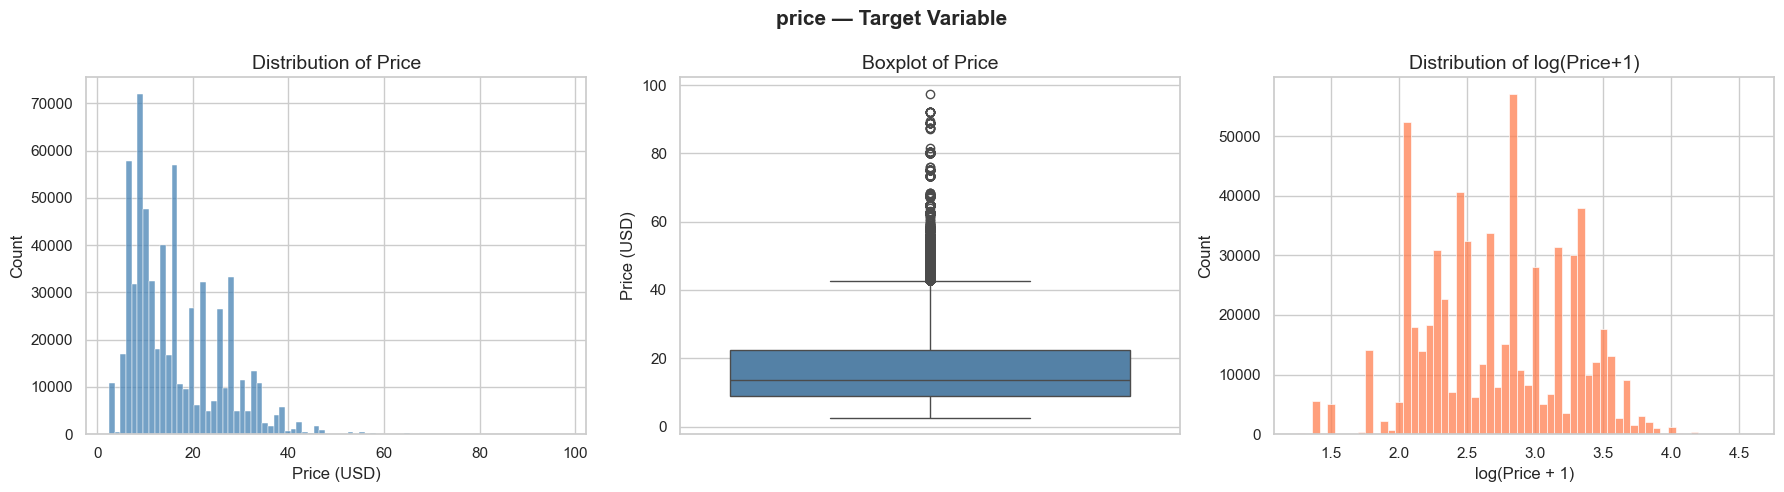

In [58]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['price'], bins=80, color='steelblue', ax=axes[0])
axes[0].set_title('Distribution of Price')
axes[0].set_xlabel('Price (USD)')

sns.boxplot(y=df['price'], color='steelblue', ax=axes[1])
axes[1].set_title('Boxplot of Price')
axes[1].set_ylabel('Price (USD)')

sns.histplot(np.log1p(df['price']), bins=60, color='coral', ax=axes[2])
axes[2].set_title('Distribution of log(Price+1)')
axes[2].set_xlabel('log(Price + 1)')

plt.suptitle('price — Target Variable', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

 **NOTE:** จากกราฟมีการเบ้ขวาหลัง log-transform เข้าใกล้ normal มากขึ้น

---
# Part 2 — Ride Features

### 2.1 distance  ระยะทางการเดินทาง

In [59]:
quick_summary('distance')

  dtype     : float64
  non-null  : 637,976
  missing   : 0 (0.0%)
  min/max   : 0.02 / 7.86
  mean±std  : 2.189 ± 1.135
  median    : 2.16
  skewness  : 0.8168


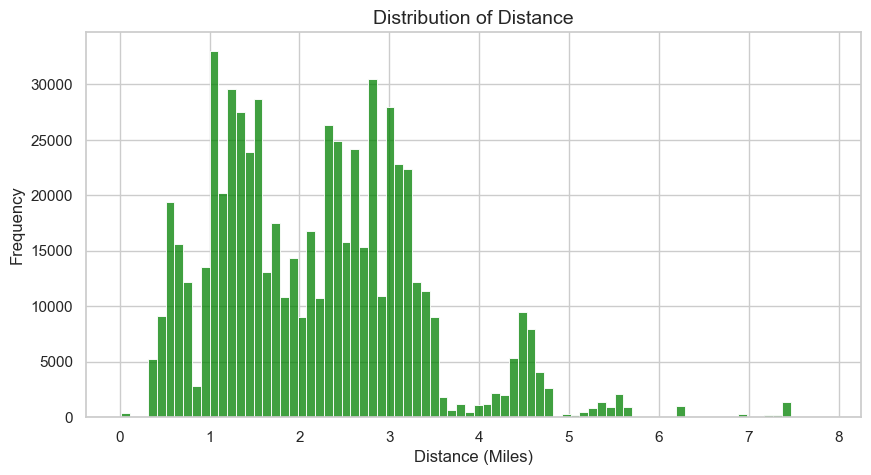

In [60]:
plt.figure(figsize=(10, 5))
sns.histplot(df['distance'], bins=80, color='green')
plt.title('Distribution of Distance')
plt.xlabel('Distance (Miles)')
plt.ylabel('Frequency')
plt.show()

 **NOTE:** จากกราฟมีการเบ้ขวาเล็กน้อย คาดว่า `distance` จะ correlate กับ `price` สูงมาก

### 2.2 surge_multiplier ตัวคูณราคาช่วง demand สูง

In [61]:
quick_summary('surge_multiplier')
print("\nValue counts:")
print(df['surge_multiplier'].value_counts().sort_index())

  dtype     : float64
  non-null  : 637,976
  missing   : 0 (0.0%)
  min/max   : 1 / 3
  mean±std  : 1.015 ± 0.09542
  median    : 1
  skewness  : 7.9690

Value counts:
surge_multiplier
1.00    617001
1.25     11085
1.50      5065
1.75      2420
2.00      2239
2.50       154
3.00        12
Name: count, dtype: int64


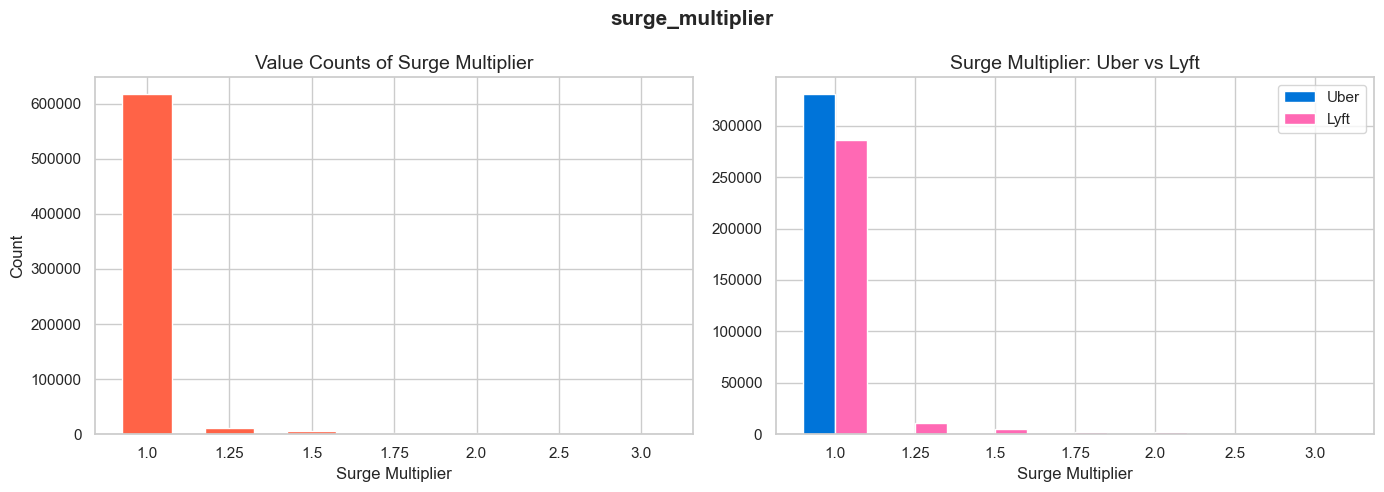

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

surge_counts = df['surge_multiplier'].value_counts().sort_index()
axes[0].bar(surge_counts.index.astype(str), surge_counts.values, color='tomato', width=0.6)
axes[0].set_title('Value Counts of Surge Multiplier')
axes[0].set_xlabel('Surge Multiplier')
axes[0].set_ylabel('Count')

uber_surge = df[df['cab_type'] == 'Uber']['surge_multiplier'].value_counts().sort_index()
lyft_surge = df[df['cab_type'] == 'Lyft']['surge_multiplier'].value_counts().sort_index()
all_vals = surge_counts.index
x = np.arange(len(all_vals))
axes[1].bar(x - 0.2, uber_surge.reindex(all_vals, fill_value=0), 0.4, label='Uber', color='#0074D9')
axes[1].bar(x + 0.2, lyft_surge.reindex(all_vals, fill_value=0), 0.4, label='Lyft', color='#FF69B4')
axes[1].set_xticks(x)
axes[1].set_xticklabels(all_vals.astype(str))
axes[1].set_title('Surge Multiplier: Uber vs Lyft')
axes[1].set_xlabel('Surge Multiplier')
axes[1].legend()

plt.suptitle('surge_multiplier', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

**NOTE:** ค่าส่วนใหญ่เป็น 1.0 Uber = 1.0 ทั้งหมด, Lyft มีหลายระดับ  

### 2.3 name  ประเภทบริการ 

In [63]:
quick_summary('name')

  dtype     : str
  non-null  : 637,976
  missing   : 0 (0.0%)
  unique    : 12
  top 5     :
name
UberXL       55096
WAV          55096
Black SUV    55096
Black        55095
UberX        55094
Name: count, dtype: int64


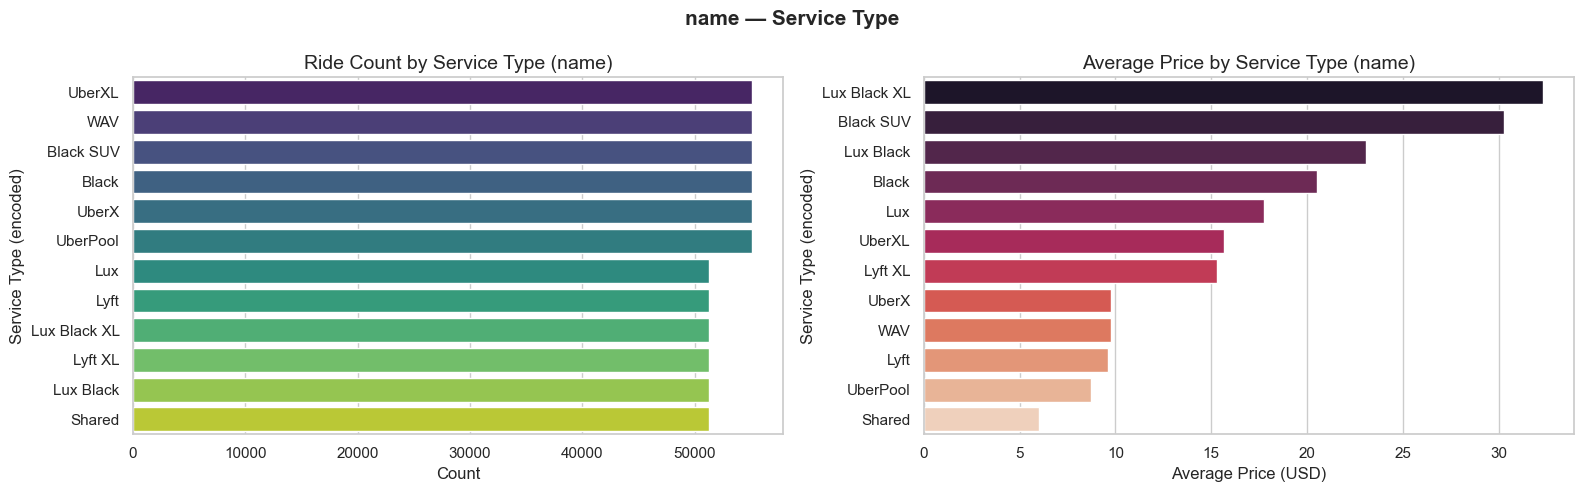

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

name_counts = df['name'].value_counts()
sns.barplot(x=name_counts.values, y=name_counts.index.astype(str), palette='viridis', ax=axes[0])
axes[0].set_title('Ride Count by Service Type (name)')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('Service Type (encoded)')

avg_price = df.groupby('name')['price'].mean().sort_values(ascending=False)
sns.barplot(x=avg_price.values, y=avg_price.index.astype(str), palette='rocket', ax=axes[1])
axes[1].set_title('Average Price by Service Type (name)')
axes[1].set_xlabel('Average Price (USD)')
axes[1].set_ylabel('Service Type (encoded)')

plt.suptitle('name — Service Type', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

**NOTE:** ราคาเฉลี่ยต่างกันมากระหว่างแต่ละ service type — tier สูงแพงกว่าชัดเจน  

### 2.4 cab_type / cab_type_Uber  แบรนด์

In [65]:
quick_summary('cab_type_Uber',df_encode)

  dtype     : bool
  non-null  : 637,976
  missing   : 0 (0.0%)
  min/max   : 0 / 1
  mean±std  : 0.5182 ± 0.4997
  median    : 1
  skewness  : -0.0727


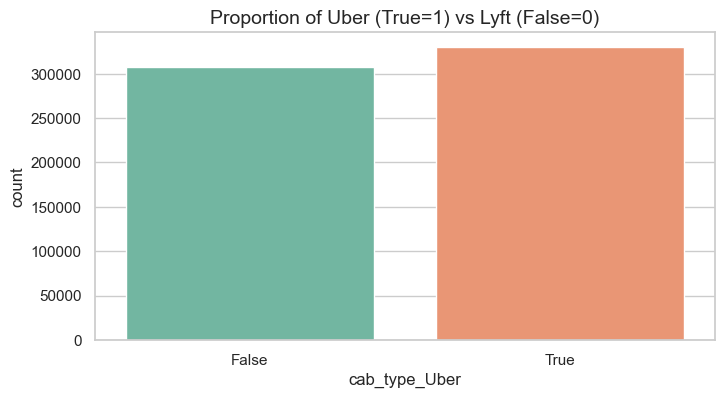

Count per brand:
cab_type_Uber
Uber (1)    330568
Lyft (0)    307408
Name: count, dtype: int64


In [66]:
plt.figure(figsize=(8, 4))
sns.countplot(x='cab_type_Uber', data=df_encode, palette='Set2')
plt.title('Proportion of Uber (True=1) vs Lyft (False=0)')
plt.xlabel('cab_type_Uber')
plt.show()

print("Count per brand:")
vc = df_encode['cab_type_Uber'].value_counts()
print(vc.rename({1: 'Uber (1)', 0: 'Lyft (0)'}))

**NOTE:** Dataset balanced ระหว่าง Uber และ Lyft  

### 2.5 source จุดรับผู้โดยสาร

In [67]:
quick_summary('source')

  dtype     : str
  non-null  : 637,976
  missing   : 0 (0.0%)
  unique    : 12
  top 5     :
source
Financial District    54197
Back Bay              53201
Theatre District      53201
Boston University     53172
North End             53171
Name: count, dtype: int64


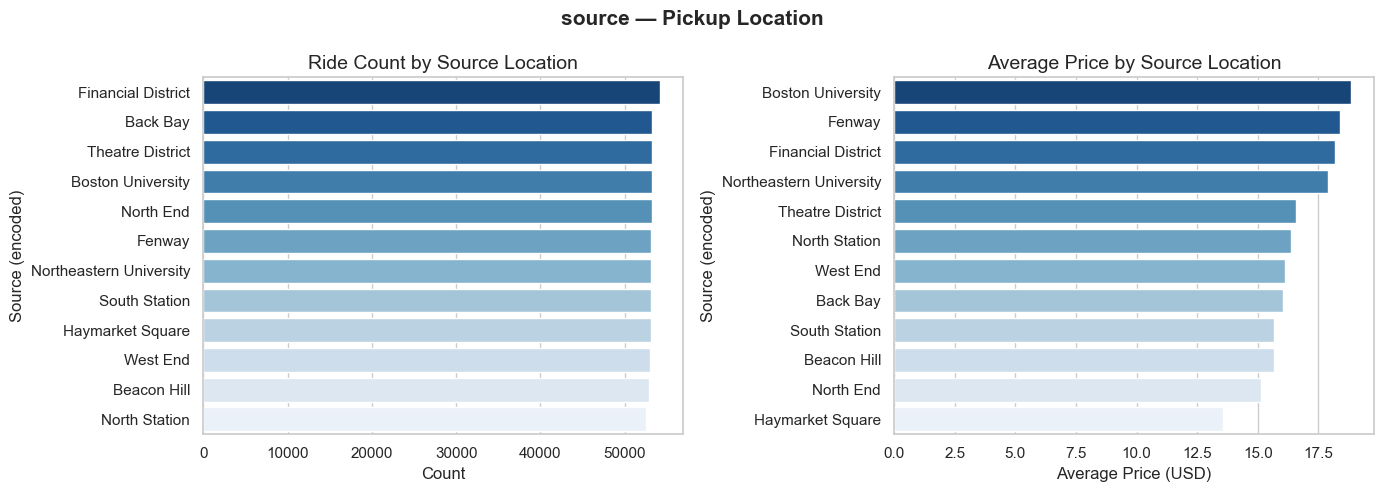

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

src_counts = df['source'].value_counts()
sns.barplot(x=src_counts.values, y=src_counts.index.astype(str), palette='Blues_r', ax=axes[0])
axes[0].set_title('Ride Count by Source Location')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('Source (encoded)')

avg_price_src = df.groupby('source')['price'].mean().sort_values(ascending=False)
sns.barplot(x=avg_price_src.values, y=avg_price_src.index.astype(str), palette='Blues_r', ax=axes[1])
axes[1].set_title('Average Price by Source Location')
axes[1].set_xlabel('Average Price (USD)')
axes[1].set_ylabel('Source (encoded)')

plt.suptitle('source — Pickup Location', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

**NOTE:** จำนวน ride ค่อนข้าง balanced แต่ ราคาเฉลี่ยแตกต่างกันบ้างตาม location

### 2.6 destination จุดส่งผู้โดยสาร

In [69]:
quick_summary('destination')

  dtype     : str
  non-null  : 637,976
  missing   : 0 (0.0%)
  unique    : 12
  top 5     :
destination
Financial District    54192
Back Bay              53190
Theatre District      53189
Haymarket Square      53171
Boston University     53171
Name: count, dtype: int64


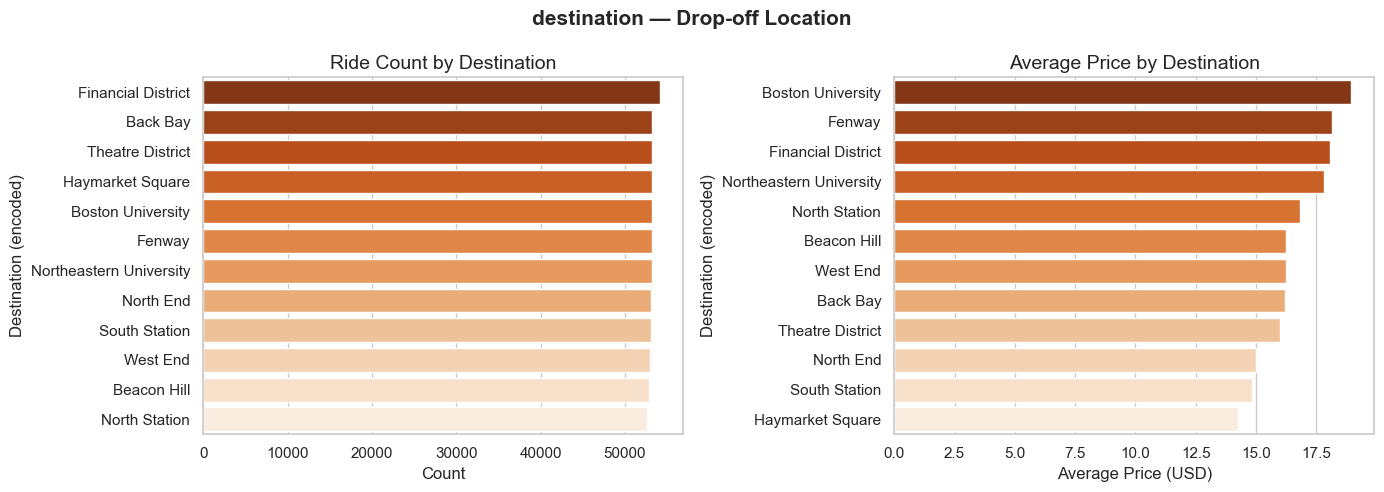

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dst_counts = df['destination'].value_counts()
sns.barplot(x=dst_counts.values, y=dst_counts.index.astype(str), palette='Oranges_r', ax=axes[0])
axes[0].set_title('Ride Count by Destination')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('Destination (encoded)')

avg_price_dst = df.groupby('destination')['price'].mean().sort_values(ascending=False)
sns.barplot(x=avg_price_dst.values, y=avg_price_dst.index.astype(str), palette='Oranges_r', ax=axes[1])
axes[1].set_title('Average Price by Destination')
axes[1].set_xlabel('Average Price (USD)')
axes[1].set_ylabel('Destination (encoded)')

plt.suptitle('destination — Drop-off Location', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

**NOTE:** Pattern คล้ายกับ `source` อาจ engineer feature ใหม่จากคู่นี้

---
# Part 3 — Time Features

### 3.1 hour — ชั่วโมงที่เรียกรถ

In [71]:
quick_summary('hour')

  dtype     : int64
  non-null  : 637,976
  missing   : 0 (0.0%)
  min/max   : 0 / 23
  mean±std  : 11.62 ± 6.949
  median    : 12
  skewness  : -0.0457


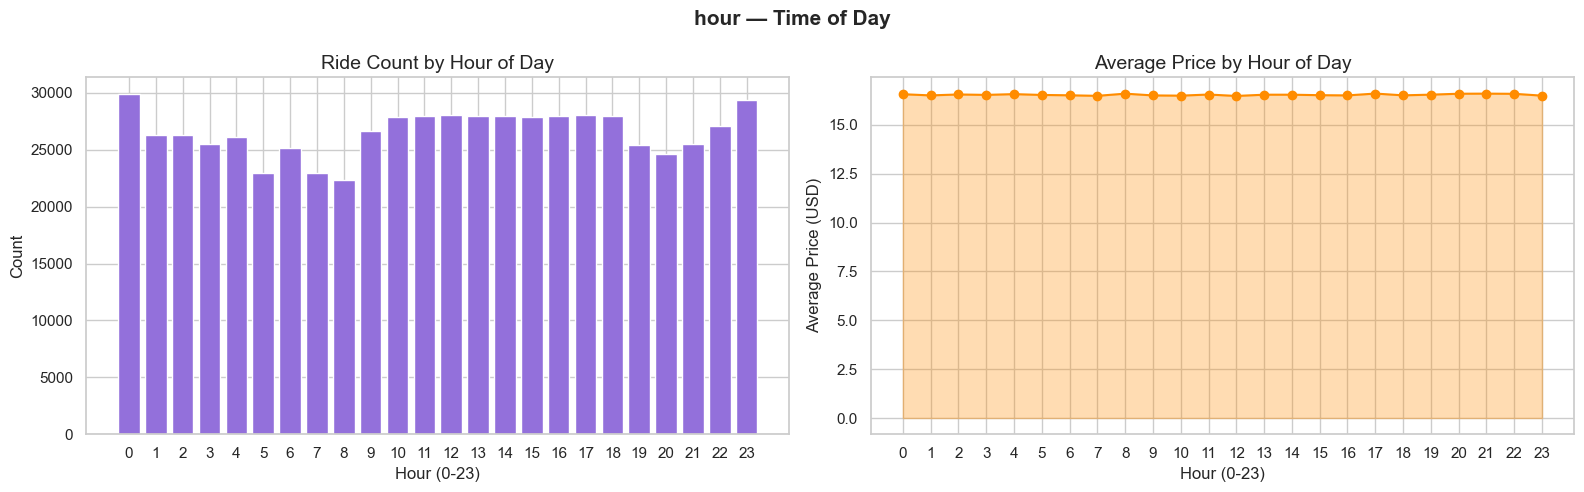

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

hour_counts = df['hour'].value_counts().sort_index()
axes[0].bar(hour_counts.index, hour_counts.values, color='mediumpurple')
axes[0].set_title('Ride Count by Hour of Day')
axes[0].set_xlabel('Hour (0-23)')
axes[0].set_ylabel('Count')
axes[0].set_xticks(range(0, 24))

avg_price_hour = df.groupby('hour')['price'].mean()
axes[1].plot(avg_price_hour.index, avg_price_hour.values, marker='o', color='darkorange')
axes[1].fill_between(avg_price_hour.index, avg_price_hour.values, alpha=0.3, color='darkorange')
axes[1].set_title('Average Price by Hour of Day')
axes[1].set_xlabel('Hour (0-23)')
axes[1].set_ylabel('Average Price (USD)')
axes[1].set_xticks(range(0, 24))

plt.suptitle('hour — Time of Day', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

**NOTE:** ไม่ค่อยส่งผลอะไรต่อราคาโดยตรง — ride count กระจายสม่ำเสมอตลอดทั้งวัน  

### 3.2 day วันในสัปดาห์

In [73]:
quick_summary('day')

  dtype     : int64
  non-null  : 637,976
  missing   : 0 (0.0%)
  min/max   : 1 / 30
  mean±std  : 17.8 ± 9.982
  median    : 17
  skewness  : -0.3760


### 3.3 month เดือน

In [74]:
quick_summary('month')

  dtype     : int64
  non-null  : 637,976
  missing   : 0 (0.0%)
  min/max   : 11 / 12
  mean±std  : 11.59 ± 0.4925
  median    : 12
  skewness  : -0.3515


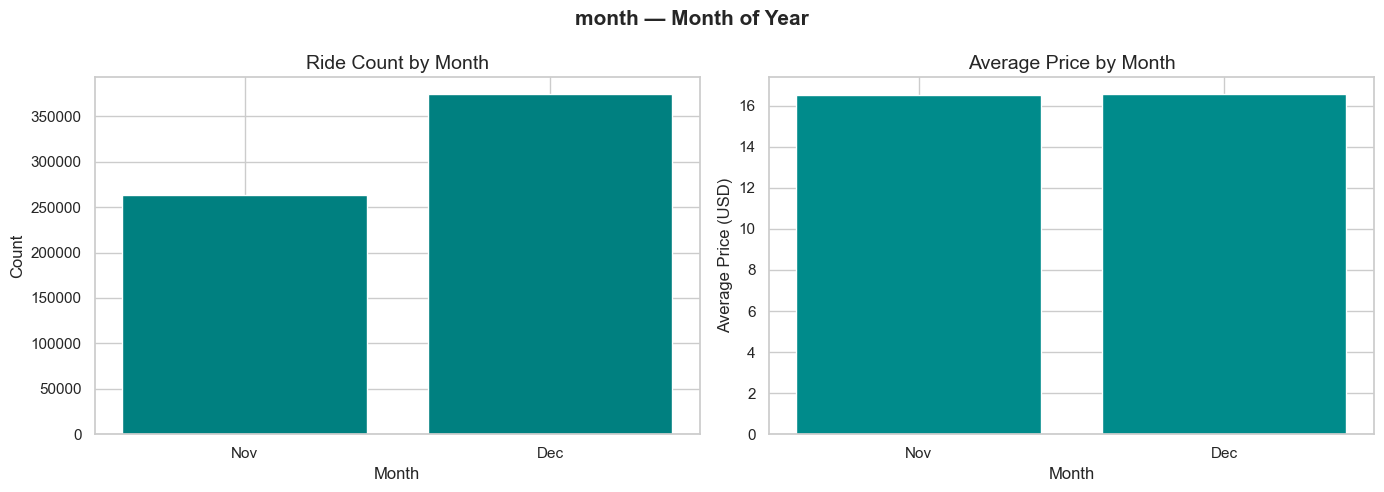

In [75]:
month_labels = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
                7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

month_counts = df['month'].value_counts().sort_index()
axes[0].bar([month_labels.get(m, m) for m in month_counts.index], month_counts.values, color='teal')
axes[0].set_title('Ride Count by Month')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Count')

avg_price_month = df.groupby('month')['price'].mean()
axes[1].bar([month_labels.get(m, m) for m in avg_price_month.index], avg_price_month.values, color='darkcyan')
axes[1].set_title('Average Price by Month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Average Price (USD)')

plt.suptitle('month — Month of Year', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

**NOTE:** ถ้า dataset มีแค่ 1–2 เดือน feature นี้แทบไม่มีประโยชน์ในการนำไปใช้ต่อ

---
# Part 4 — Weather Features

### 4.1 temperature & apparentTemperature — อุณหภูมิ

In [116]:
for col in ['temperature', 'apparentTemperature']:
    if col in df.columns:
        print(f'=== {col} ===')
        quick_summary(col)
        print()

=== temperature ===
  dtype     : float64
  non-null  : 637,976
  missing   : 0 (0.0%)
  min/max   : 18.91 / 57.22
  mean±std  : 39.58 ± 6.726
  median    : 40.49
  skewness  : -0.6092

=== apparentTemperature ===
  dtype     : float64
  non-null  : 637,976
  missing   : 0 (0.0%)
  min/max   : 12.13 / 57.22
  mean±std  : 35.88 ± 7.917
  median    : 35.9
  skewness  : -0.3936



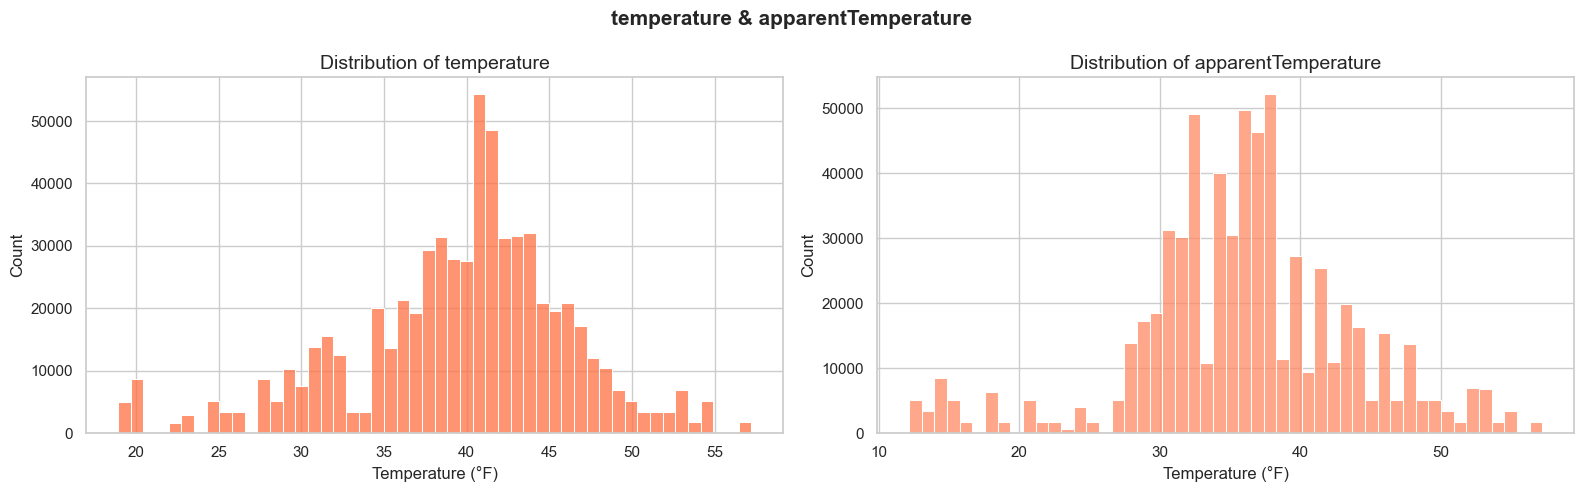

In [117]:
temp_cols = [c for c in ['temperature', 'apparentTemperature'] if c in df.columns]
fig, axes = plt.subplots(1, len(temp_cols), figsize=(8 * len(temp_cols), 5))
if len(temp_cols) == 1: axes = [axes]

colors = ['#FF7043', '#FF8A65']
for ax, col, color in zip(axes, temp_cols, colors):
    sns.histplot(df[col], bins=50, color=color, ax=ax)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel('Temperature (°F)')

plt.suptitle('temperature & apparentTemperature', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

**NOTE:** ช่วงอุณหภูมิสะท้อน Boston ปลายปี — มักอยู่ช่วง 30–60°F

### 4.2 humidity  ความชื้นสัมพัทธ์

In [118]:
if 'humidity' in df.columns:
    quick_summary('humidity')

  dtype     : float64
  non-null  : 637,976
  missing   : 0 (0.0%)
  min/max   : 0.38 / 0.96
  mean±std  : 0.7411 ± 0.1386
  median    : 0.71
  skewness  : -0.0748


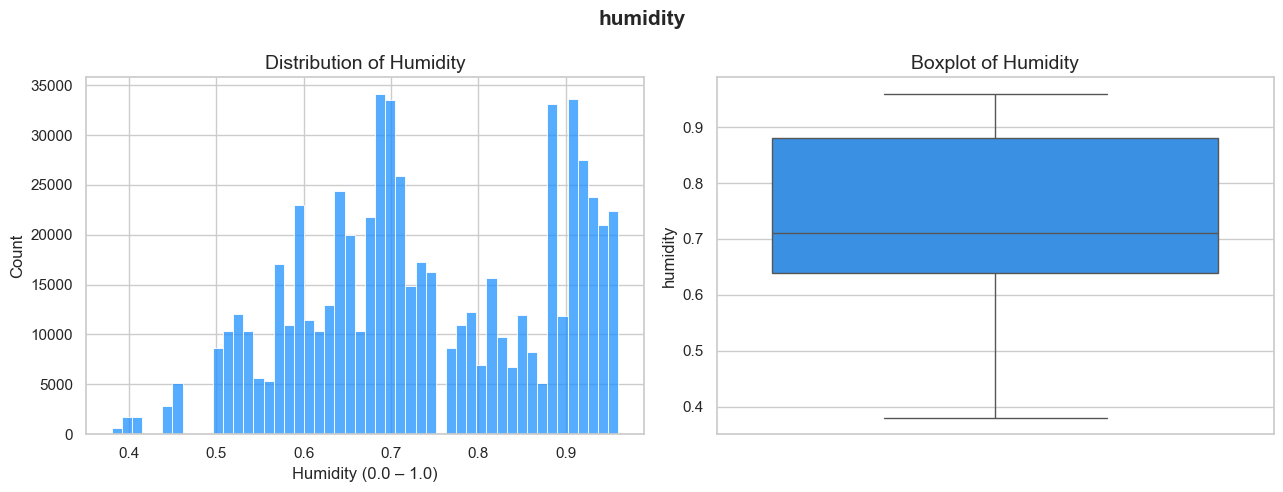

In [119]:
if 'humidity' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    sns.histplot(df['humidity'], bins=50, color='dodgerblue', ax=axes[0])
    axes[0].set_title('Distribution of Humidity')
    axes[0].set_xlabel('Humidity (0.0 – 1.0)')
    sns.boxplot(y=df['humidity'], color='dodgerblue', ax=axes[1])
    axes[1].set_title('Boxplot of Humidity')
    plt.suptitle('humidity', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()

**NOTE:** Boston ช่วงฤดูหนาวมีความชื้นค่อนข้างสูง — ตรวจสอบ outlier > 1.0 ด้วย

### 4.3 windSpeed & windGust ความเร็วลม

In [120]:
wind_cols = [c for c in ['windSpeed', 'windGust'] if c in df.columns]
for col in wind_cols:
    print(f'=== {col} ===')
    quick_summary(col)
    print()

=== windSpeed ===
  dtype     : float64
  non-null  : 637,976
  missing   : 0 (0.0%)
  min/max   : 0.45 / 15
  mean±std  : 6.187 ± 3.148
  median    : 5.91
  skewness  : 0.4512

=== windGust ===
  dtype     : float64
  non-null  : 637,976
  missing   : 0 (0.0%)
  min/max   : 0.8 / 27.25
  mean±std  : 8.471 ± 5.289
  median    : 7.55
  skewness  : 1.1184



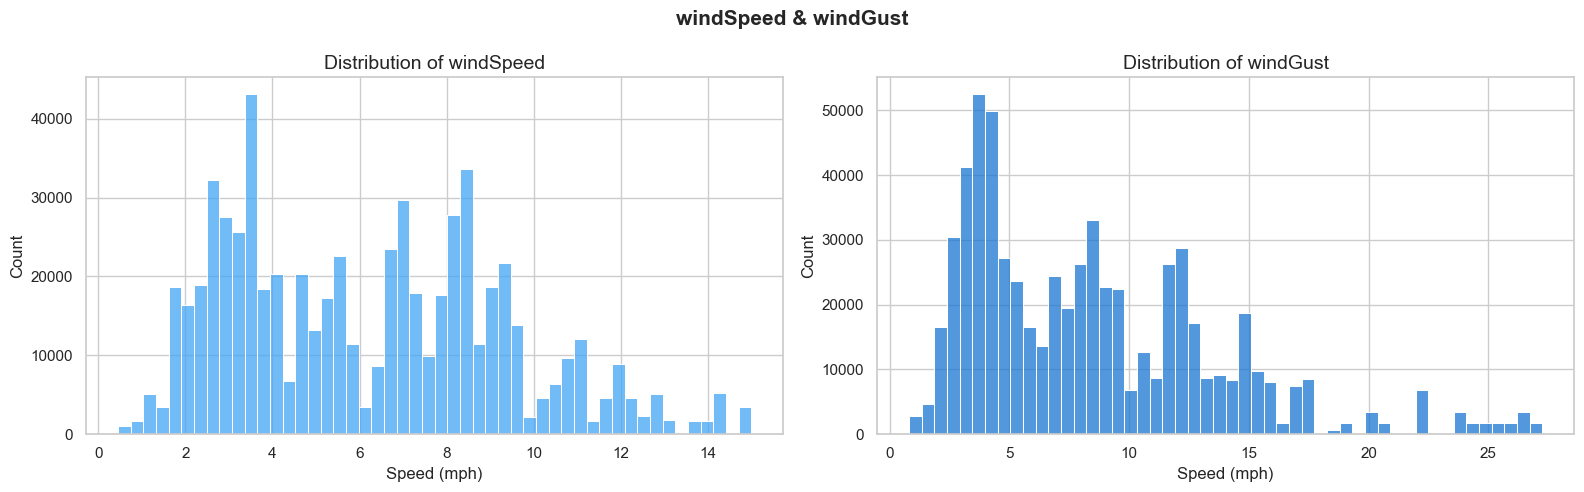

In [121]:
wind_cols = [c for c in ['windSpeed', 'windGust'] if c in df.columns]
if wind_cols:
    fig, axes = plt.subplots(1, len(wind_cols), figsize=(8 * len(wind_cols), 5))
    if len(wind_cols) == 1: axes = [axes]
    colors = ['#42A5F5', '#1976D2']
    for ax, col, color in zip(axes, wind_cols, colors):
        sns.histplot(df[col], bins=50, color=color, ax=ax)
        ax.set_title(f'Distribution of {col}')
        ax.set_xlabel('Speed (mph)')
    plt.suptitle('windSpeed & windGust', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()

**NOTE:** `windGust` มักสูงกว่าและ skewed กว่า `windSpeed`  

### 4.4 windBearing — ทิศทางลม

In [122]:
if 'windBearing' in df.columns:
    quick_summary('windBearing')

  dtype     : int64
  non-null  : 637,976
  missing   : 0 (0.0%)
  min/max   : 2 / 356
  mean±std  : 220.1 ± 99.09
  median    : 258
  skewness  : -0.6270


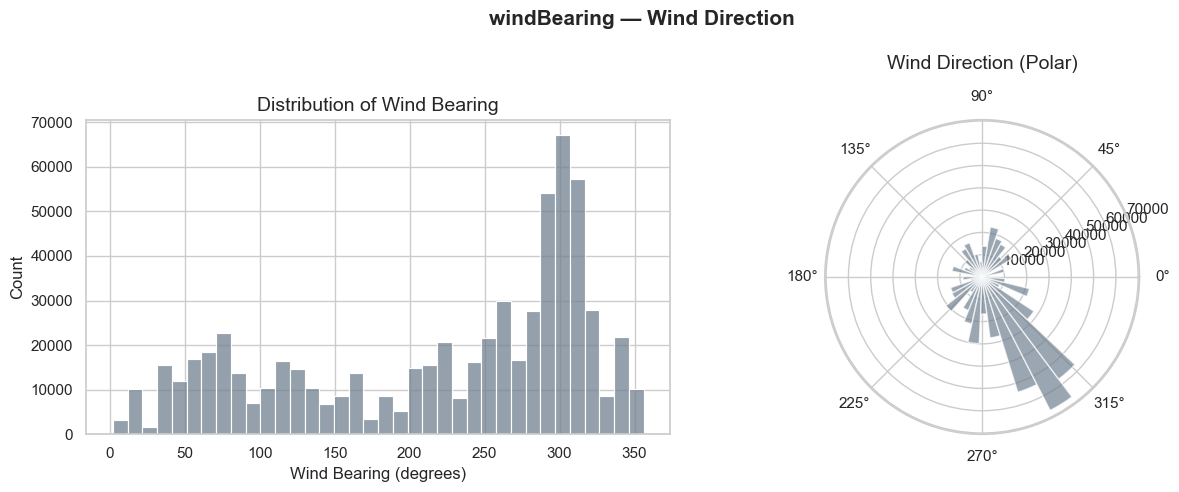

In [123]:
if 'windBearing' in df.columns:
    fig = plt.figure(figsize=(13, 5))
    ax1 = fig.add_subplot(121)
    sns.histplot(df['windBearing'], bins=36, color='slategray', ax=ax1)
    ax1.set_title('Distribution of Wind Bearing')
    ax1.set_xlabel('Wind Bearing (degrees)')
    ax2 = fig.add_subplot(122, projection='polar')
    ax2.hist(np.deg2rad(df['windBearing']), bins=36, color='slategray', alpha=0.7)
    ax2.set_title('Wind Direction (Polar)', pad=15)
    plt.suptitle('windBearing — Wind Direction', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()

**NOTE:**

### 4.5 visibility — ทัศนวิสัย

In [124]:
if 'visibility' in df.columns:
    quick_summary('visibility')

  dtype     : float64
  non-null  : 637,976
  missing   : 0 (0.0%)
  min/max   : 0.717 / 10
  mean±std  : 8.469 ± 2.602
  median    : 9.88
  skewness  : -1.5081


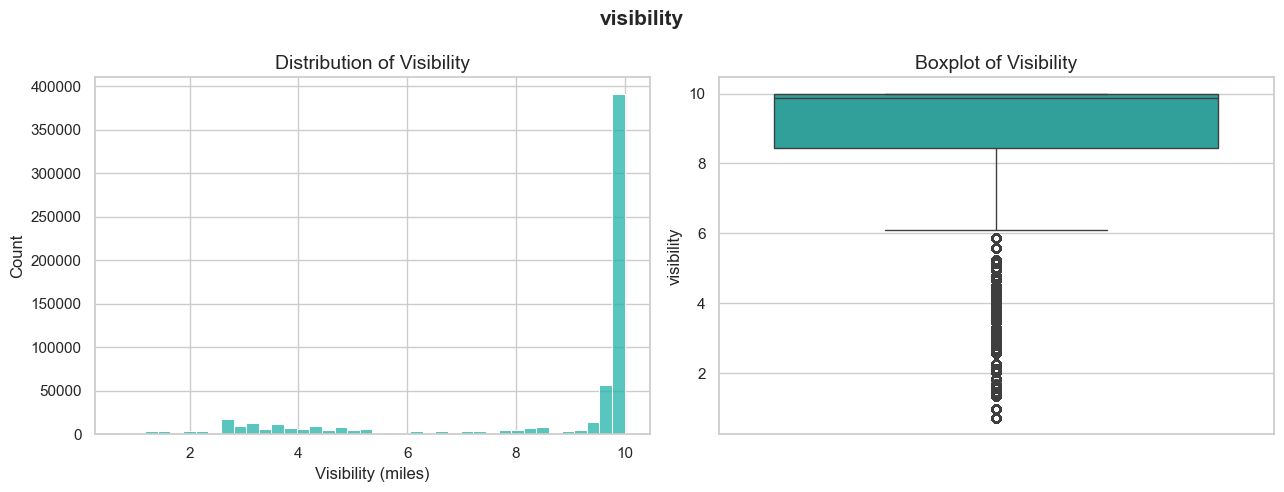

In [125]:
if 'visibility' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    sns.histplot(df['visibility'], bins=40, color='lightseagreen', ax=axes[0])
    axes[0].set_title('Distribution of Visibility')
    axes[0].set_xlabel('Visibility (miles)')
    sns.boxplot(y=df['visibility'], color='lightseagreen', ax=axes[1])
    axes[1].set_title('Boxplot of Visibility')
    plt.suptitle('visibility', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()

### 4.6 cloudCover — ความหนาแน่นเมฆ

In [126]:
if 'cloudCover' in df.columns:
    quick_summary('cloudCover')

  dtype     : float64
  non-null  : 637,976
  missing   : 0 (0.0%)
  min/max   : 0 / 1
  mean±std  : 0.6863 ± 0.3586
  median    : 0.82
  skewness  : -0.7320


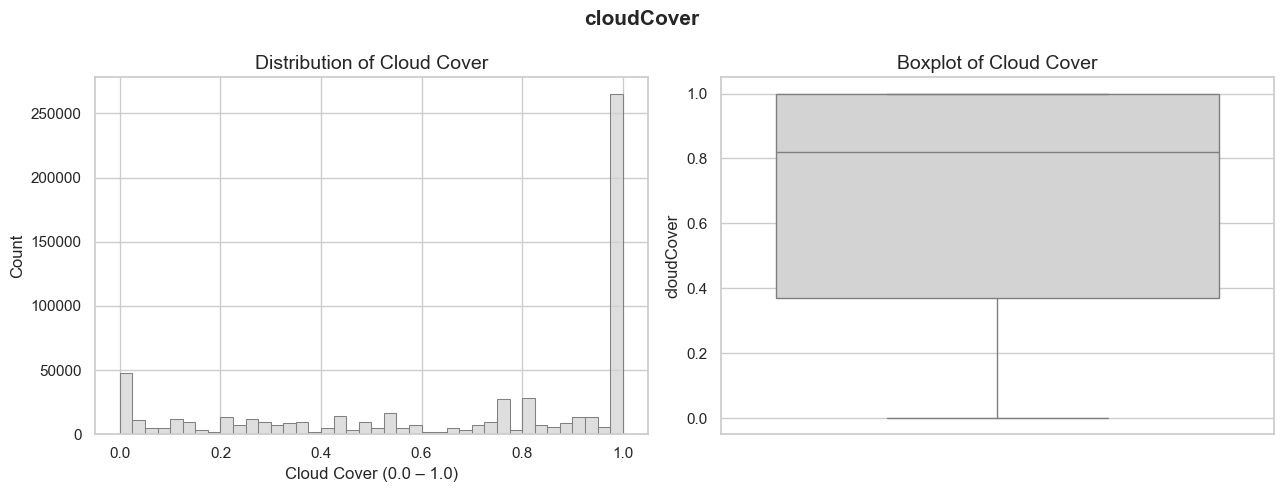

In [127]:
if 'cloudCover' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    sns.histplot(df['cloudCover'], bins=40, color='lightgray', edgecolor='gray', ax=axes[0])
    axes[0].set_title('Distribution of Cloud Cover')
    axes[0].set_xlabel('Cloud Cover (0.0 – 1.0)')
    sns.boxplot(y=df['cloudCover'], color='lightgray', ax=axes[1])
    axes[1].set_title('Boxplot of Cloud Cover')
    plt.suptitle('cloudCover', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()

### 4.7 uvIndex — ดัชนี UV

In [128]:
if 'uvIndex' in df.columns:
    quick_summary('uvIndex')
    print("\nValue counts:", df['uvIndex'].value_counts().sort_index().to_dict())

  dtype     : int64
  non-null  : 637,976
  missing   : 0 (0.0%)
  min/max   : 0 / 2
  mean±std  : 0.249 ± 0.4743
  median    : 0
  skewness  : 1.6810

Value counts: {0: 491206, 1: 134664, 2: 12106}


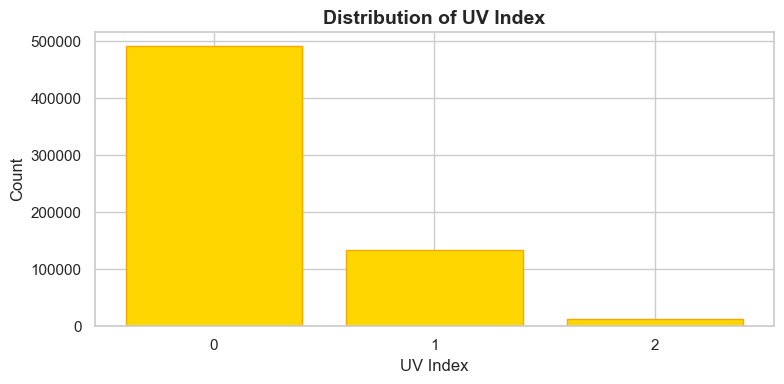

In [129]:
if 'uvIndex' in df.columns:
    uv_counts = df['uvIndex'].value_counts().sort_index()
    plt.figure(figsize=(8, 4))
    plt.bar(uv_counts.index.astype(str), uv_counts.values, color='gold', edgecolor='orange')
    plt.title('Distribution of UV Index', fontsize=14, fontweight='bold')
    plt.xlabel('UV Index')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

### 4.8 pressure — ความกดอากาศ

In [130]:
if 'pressure' in df.columns:
    quick_summary('pressure')

  dtype     : float64
  non-null  : 637,976
  missing   : 0 (0.0%)
  min/max   : 988.1 / 1036
  mean±std  : 1010 ± 13.48
  median    : 1009
  skewness  : 0.1543


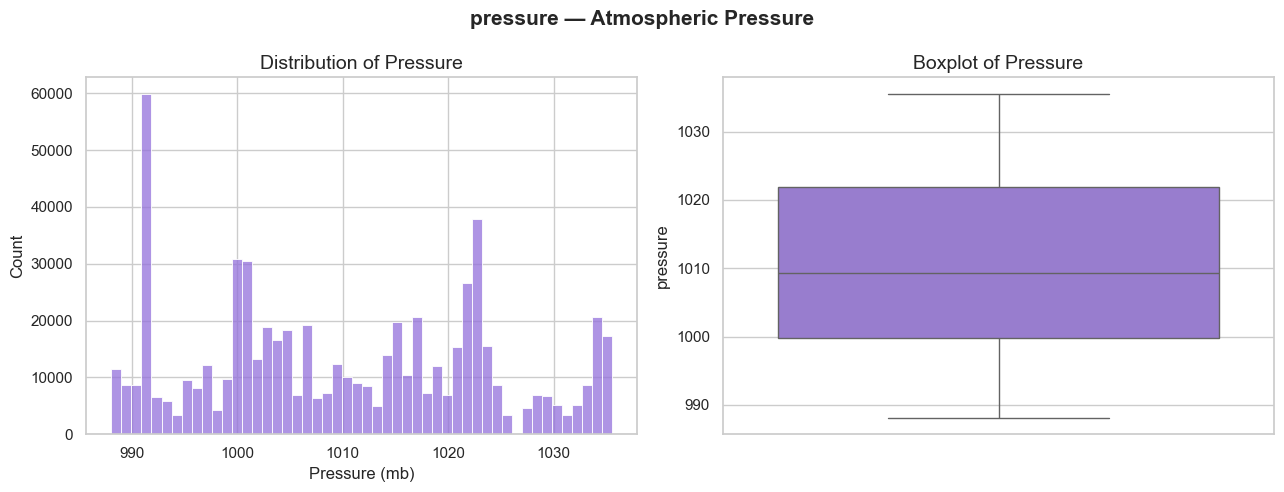

In [131]:
if 'pressure' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    sns.histplot(df['pressure'], bins=50, color='mediumpurple', ax=axes[0])
    axes[0].set_title('Distribution of Pressure')
    axes[0].set_xlabel('Pressure (mb)')
    sns.boxplot(y=df['pressure'], color='mediumpurple', ax=axes[1])
    axes[1].set_title('Boxplot of Pressure')
    plt.suptitle('pressure — Atmospheric Pressure', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()

### 4.9 dewPoint — จุดน้ำค้าง

In [132]:
if 'dewPoint' in df.columns:
    quick_summary('dewPoint')

  dtype     : float64
  non-null  : 637,976
  missing   : 0 (0.0%)
  min/max   : 4.39 / 50.67
  mean±std  : 31.65 ± 9.141
  median    : 30.69
  skewness  : -0.4979


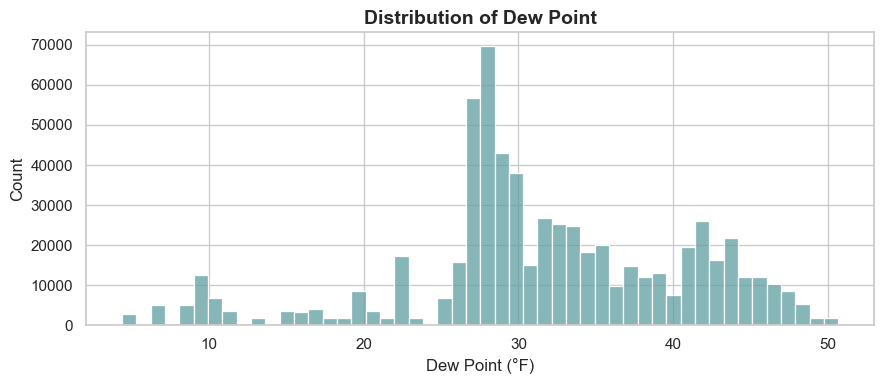

In [133]:
if 'dewPoint' in df.columns:
    plt.figure(figsize=(9, 4))
    sns.histplot(df['dewPoint'], bins=50, color='cadetblue')
    plt.title('Distribution of Dew Point', fontsize=14, fontweight='bold')
    plt.xlabel('Dew Point (°F)')
    plt.tight_layout()
    plt.show()

### 4.10 precipIntensity & precipProbability — ฝน

In [134]:
precip_cols = [c for c in ['precipIntensity', 'precipProbability'] if c in df.columns]
for col in precip_cols:
    print(f'=== {col} ===')
    quick_summary(col)
    print()

=== precipIntensity ===
  dtype     : float64
  non-null  : 637,976
  missing   : 0 (0.0%)
  min/max   : 0 / 0.1447
  mean±std  : 0.008909 ± 0.02688
  median    : 0
  skewness  : 3.3280

=== precipProbability ===
  dtype     : float64
  non-null  : 637,976
  missing   : 0 (0.0%)
  min/max   : 0 / 1
  mean±std  : 0.1459 ± 0.3288
  median    : 0
  skewness  : 2.0293



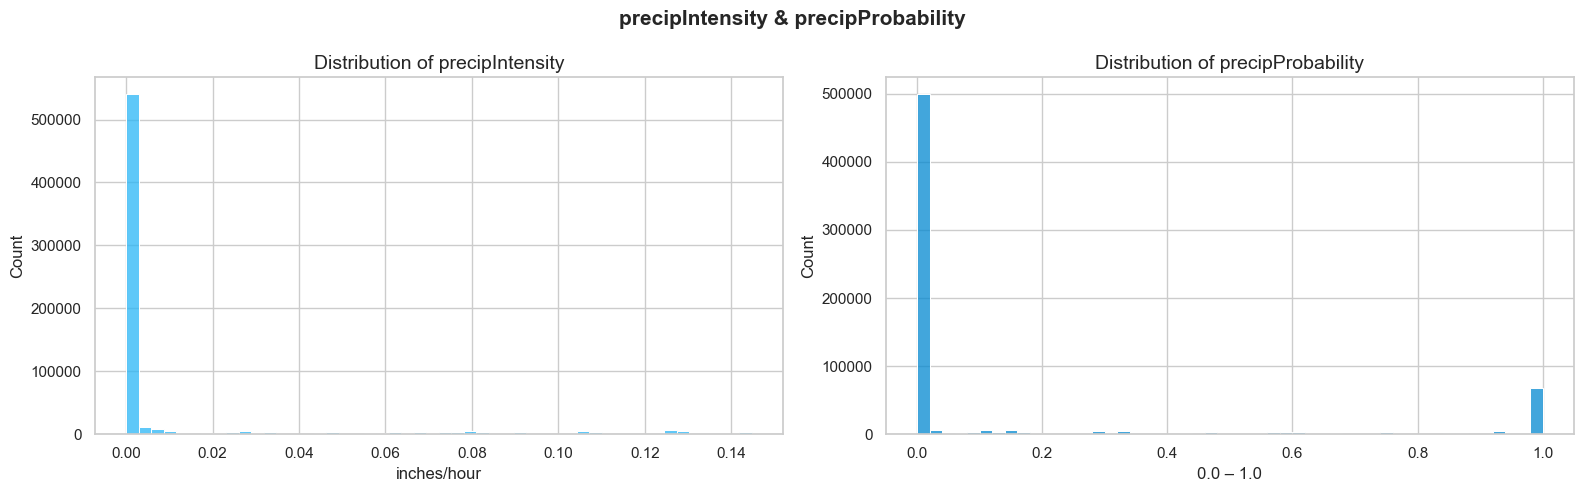

In [135]:
precip_cols = [c for c in ['precipIntensity', 'precipProbability'] if c in df.columns]
if precip_cols:
    fig, axes = plt.subplots(1, len(precip_cols), figsize=(8 * len(precip_cols), 5))
    if len(precip_cols) == 1: axes = [axes]
    colors = ['#29B6F6', '#0288D1']
    units = ['inches/hour', '0.0 – 1.0']
    for ax, col, color, unit in zip(axes, precip_cols, colors, units):
        sns.histplot(df[col], bins=50, color=color, ax=ax)
        ax.set_title(f'Distribution of {col}')
        ax.set_xlabel(unit)
    plt.suptitle('precipIntensity & precipProbability', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()

### 4.11 ozone — โอโซน  

In [136]:
if 'ozone' in df.columns:
    quick_summary('ozone')

  dtype     : float64
  non-null  : 637,976
  missing   : 0 (0.0%)
  min/max   : 269.4 / 378.9
  mean±std  : 313.5 ± 27.95
  median    : 307.4
  skewness  : 0.4148


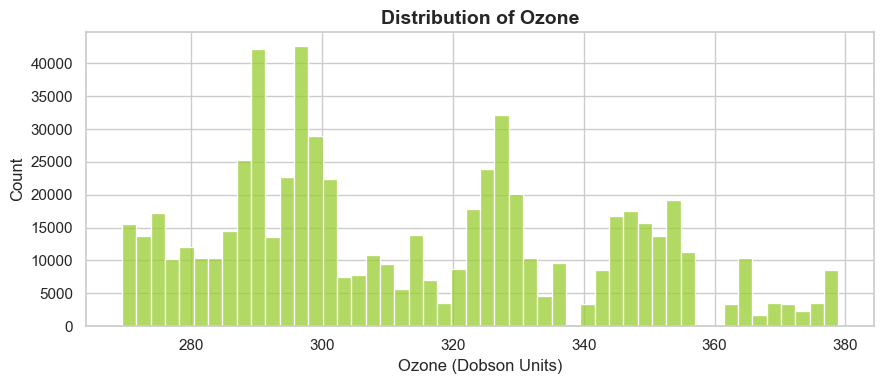

In [137]:
if 'ozone' in df.columns:
    plt.figure(figsize=(9, 4))
    sns.histplot(df['ozone'], bins=50, color='yellowgreen')
    plt.title('Distribution of Ozone', fontsize=14, fontweight='bold')
    plt.xlabel('Ozone (Dobson Units)')
    plt.tight_layout()
    plt.show()

### 4.12 moonPhase — เฟสดวงจันทร์

In [138]:
if 'moonPhase' in df.columns:
    quick_summary('moonPhase')

  dtype     : float64
  non-null  : 637,976
  missing   : 0 (0.0%)
  min/max   : 0.09 / 0.93
  mean±std  : 0.5791 ± 0.2447
  median    : 0.68
  skewness  : -0.3797


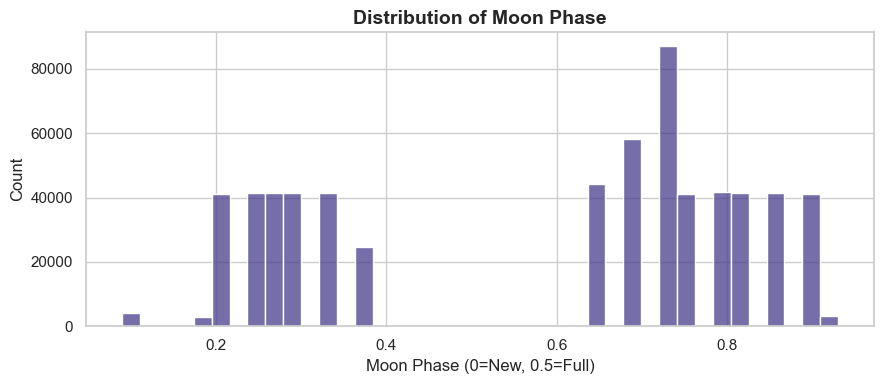

In [139]:
if 'moonPhase' in df.columns:
    plt.figure(figsize=(9, 4))
    sns.histplot(df['moonPhase'], bins=40, color='darkslateblue')
    plt.title('Distribution of Moon Phase', fontsize=14, fontweight='bold')
    plt.xlabel('Moon Phase (0=New, 0.5=Full)')
    plt.tight_layout()
    plt.show()

### 4.13 short_summary สภาพอากาศโดยรวม

In [140]:
if 'short_summary' in df.columns:
    quick_summary('short_summary')

  dtype     : str
  non-null  : 637,976
  missing   : 0 (0.0%)
  unique    : 9
  top 5     :
short_summary
Overcast          201429
Mostly Cloudy     134603
Partly Cloudy     117226
Clear              80256
Light Rain         50488
Name: count, dtype: int64


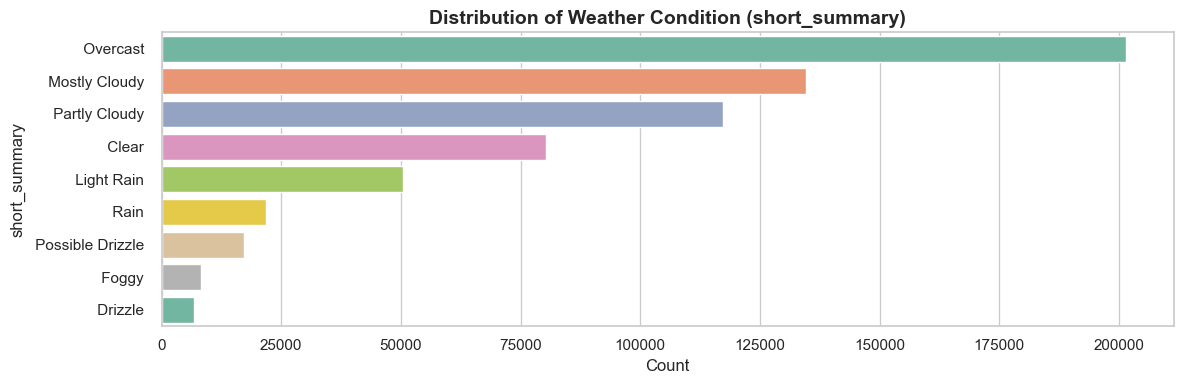


Encoded columns: ['short_summary_ Drizzle ', 'short_summary_ Foggy ', 'short_summary_ Light Rain ', 'short_summary_ Mostly Cloudy ', 'short_summary_ Overcast ', 'short_summary_ Partly Cloudy ', 'short_summary_ Possible Drizzle ', 'short_summary_ Rain ']
short_summary_ Overcast             201429
short_summary_ Mostly Cloudy        134603
short_summary_ Partly Cloudy        117226
short_summary_ Light Rain            50488
short_summary_ Rain                  21781
short_summary_ Possible Drizzle      17176
short_summary_ Foggy                  8292
short_summary_ Drizzle                6725
dtype: int64


In [141]:
# ดู string ใน cleaned file
if 'short_summary' in df.columns:
    ss_counts = df['short_summary'].value_counts()
    plt.figure(figsize=(12, 4))
    sns.barplot(x=ss_counts.values, y=ss_counts.index, palette='Set2')
    plt.title('Distribution of Weather Condition (short_summary)', fontsize=14, fontweight='bold')
    plt.xlabel('Count')
    plt.tight_layout()
    plt.show()

# ดู one-hot columns ใน encoded file
ss_cols_enc = [c for c in df_encode.columns if 'short_summary' in c.lower()]
if ss_cols_enc:
    print(f"\nEncoded columns: {ss_cols_enc}")
    print(df_encode[ss_cols_enc].sum().sort_values(ascending=False))

# Part 5 — Summary สำหรับทีม

In [142]:
# Overview: missing values + dtype ทุก column
summary_df = pd.DataFrame({
    'dtype': df.dtypes,
    'non_null': df.count(),
    'missing': df.isna().sum(),
    'missing_%': (df.isna().sum() / len(df) * 100).round(2),
    'unique': df.nunique(),
})
numeric_cols = df.select_dtypes(include='number').columns
summary_df.loc[numeric_cols, 'skewness'] = df[numeric_cols].skew().round(4)
display(summary_df)

,dtype,non_null,missing,missing_%,unique,skewness
hour,int64,637976,0,0.0,24,-0.0457
day,int64,637976,0,0.0,17,-0.3760
month,int64,637976,0,0.0,2,-0.3515
source,str,637976,0,0.0,12,NaN
destination,str,637976,0,0.0,12,NaN
cab_type,str,637976,0,0.0,2,NaN
name,str,637976,0,0.0,12,NaN
price,float64,637976,0,0.0,147,1.0457
distance,float64,637976,0,0.0,549,0.8168
surge_multiplier,float64,637976,0,0.0,7,7.9690
